In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

In [7]:
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/praktikum_ml/praktikum09/data/data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
print("Data Awal (5 Baris Teratas):")
print(data.head())
print("\nInformasi Data:")
data.info()

Data Awal (5 Baris Teratas):
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_

In [33]:
data.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


<Axes: xlabel='diagnosis', ylabel='radius_worst'>

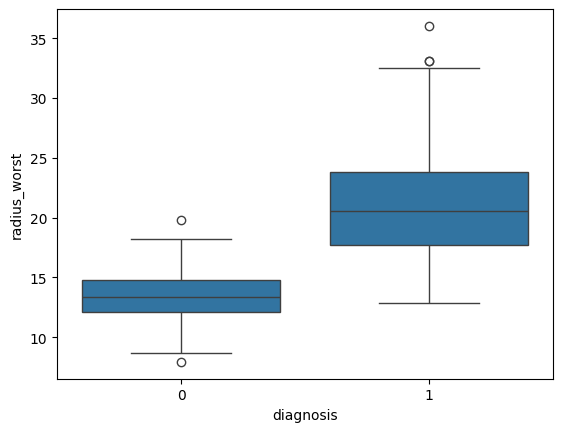

In [36]:
sns.boxplot(x='diagnosis', y='radius_worst', data=data)

In [9]:
data = data.drop(['id', 'Unnamed: 32'], axis=1)

In [10]:
data['diagnosis'] = data['diagnosis'].map({'B': 0, 'M': 1})

/tmp/ipython-input-2515935174.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='diagnosis', data=data, palette=['skyblue', 'salmon'])


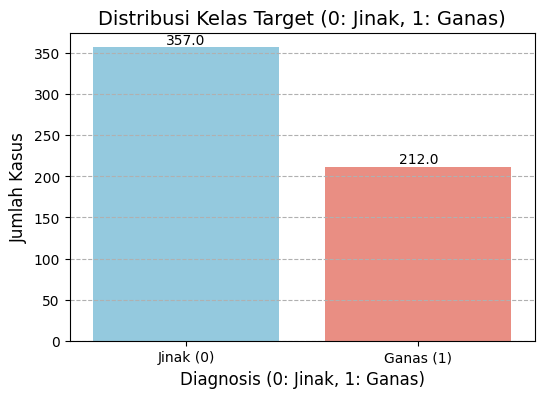

In [37]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='diagnosis', data=data, palette=['skyblue', 'salmon'])

# Opsional: Menambahkan label jumlah pada setiap bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')

plt.title('Distribusi Kelas Target (0: Jinak, 1: Ganas)', fontsize=14)
plt.xlabel('Diagnosis (0: Jinak, 1: Ganas)', fontsize=12)
plt.ylabel('Jumlah Kasus', fontsize=12)
plt.xticks([0, 1], ['Jinak (0)', 'Ganas (1)'])
plt.grid(axis='y', linestyle='--')
plt.show()

In [12]:
X = data.drop('diagnosis', axis=1) # Semua kolom kecuali 'diagnosis'
Y = data['diagnosis'] # Kolom 'diagnosis' (target)

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [14]:
print(f"\nUkuran Data Latih (X_train): {X_train.shape}")
print(f"Ukuran Data Uji (X_test): {X_test.shape}")


Ukuran Data Latih (X_train): (398, 30)
Ukuran Data Uji (X_test): (171, 30)


In [15]:
scaler = StandardScaler()

In [16]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, Y_train)

GaussianNB()

In [21]:
Y_pred = nb_model.predict(X_test_scaled)
accuracy = accuracy_score(Y_test, Y_pred)
print(f"\nAKURASI Model Gaussian Naive Bayes pada Data Uji: {accuracy:.4f}")


AKURASI Model Gaussian Naive Bayes pada Data Uji: 0.9357


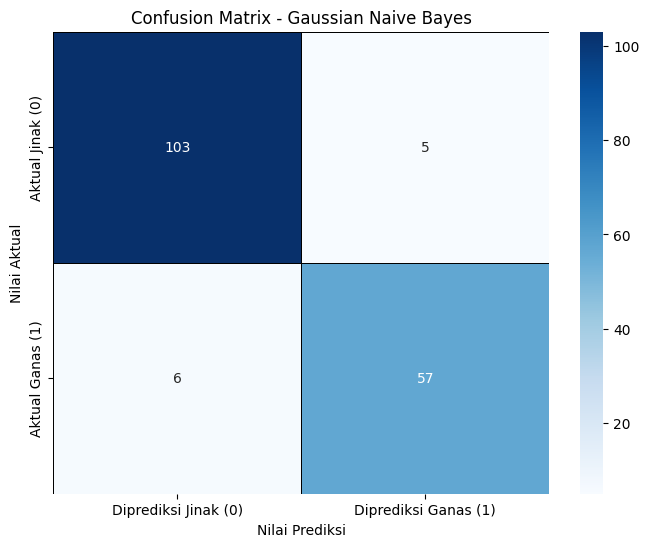

In [30]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True, # Tampilkan nilai angka di dalam sel
    fmt='d', # Format angka sebagai bilangan bulat
    cmap='Blues', # Skema warna
    cbar=True, # Tampilkan color bar
    linewidths=0.5, # Garis antar sel
    linecolor='black',
    xticklabels=['Diprediksi Jinak (0)', 'Diprediksi Ganas (1)'],
    yticklabels=['Aktual Jinak (0)', 'Aktual Ganas (1)']
)
plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.ylabel('Nilai Aktual')
plt.xlabel('Nilai Prediksi')
plt.show()
#

In [28]:
class_report = classification_report(Y_test, Y_pred)
print("\nClassification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       108
           1       0.92      0.90      0.91        63

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



**CROSS VALIDATION**

In [32]:
from sklearn.model_selection import cross_val_score
cv_nb = cross_val_score(nb_model, X, Y, cv=5, scoring='accuracy')

print("\nNaive Bayes Cross Validation Accuray (5-Fold):")
print("Scores:", cv_nb)
print("Mean Accuracy: ", cv_nb.mean())
print("Standart Deviation: ", cv_nb.std())


Naive Bayes Cross Validation Accuray (5-Fold):
Scores: [0.92105263 0.92105263 0.94736842 0.94736842 0.95575221]
Mean Accuracy:  0.9385188635305075
Standart Deviation:  0.014585994424363306
